#### Enunciado
Una empresa del sector tecnológico quiere estimar el salario mensual de sus empleados en función de
distintas variables relacionadas con su perfil profesional. Para ello, se dispone de un conjunto de datos
históricos que será utilizado para construir un modelo de regresión lineal.

#### Herramienta
Anaconda (Jupyter Notebook).

#### Conjunto de datos
Se proporciona un fichero llamado empleados.csv que contiene las siguientes variables:
- edad → Edad del empleado (años)
- experiencia → Años de experiencia laboral
- formacion → Nivel formativo (1 = FP, 2 = Grado, 3 = Máster)
- horas_extra → Número medio de horas extra mensuales
- salario → Salario mensual en euros (variable dependiente)

#### Se pide
Estudiar el proceso completo de creación de un modelo de regresión lineal.
Aplicar técnicas básicas de análisis exploratorio de datos.
Construir y evaluar un modelo predictivo.
Interpretar los coeficientes obtenidos.

#### Tareas a realizar
1. Carga y exploración de datos
- Importa las librerías necesarias (pandas, numpy, matplotlib, sklearn).
- Carga el fichero empleados.csv.
- Muestra las primeras filas del conjunto de datos.
- Comprueba si existen valores nulos o inconsistencias.

2. Análisis exploratorio
- Calcula estadísticas descriptivas básicas.
- Representa gráficamente la relación entre las variables independientes y el salario.
- Comenta brevemente qué variables parecen tener mayor relación con el salario.

3. Preparación de los datos
- Separa las variables independientes (X) y la variable dependiente (y).
- Divide el conjunto de datos en conjunto de entrenamiento y de prueba (por ejemplo, 80 % / 20 %).
- Justifica brevemente por qué es necesaria esta división.

4. Construcción del modelo
- Crea un modelo de regresión lineal.
- Entrena el modelo con los datos de entrenamiento.
- Muestra la ecuación del modelo obtenido.

5. Evaluación del modelo
- Realiza predicciones sobre el conjunto de prueba.
- Calcula al menos una métrica de evaluación (R², MAE o MSE).
- Interpreta el resultado obtenido.

6. Interpretación
- Explica qué significado tienen los coeficientes del modelo.
- Indica qué variable tiene mayor impacto en el salario según el modelo.
- Comenta una posible limitación del modelo construido

In [30]:
'''1. Carga y exploración de datos
- Importa las librerías necesarias (pandas, numpy, matplotlib, sklearn).
- Carga el fichero empleados.csv.
- Muestra las primeras filas del conjunto de datos.
- Comprueba si existen valores nulos o inconsistencias.'''
import pandas as pd

df_empleados = pd.read_csv("empleados_v2.0.csv")
df_empleados.head()

print(df_empleados.head())
print(df_empleados.isnull().any())

   edad  experiencia  formacion  horas_extra  salario
0    50           24          1            0     2616
1    36            8          2            8     2372
2    29            2          3            5     1955
3    42           18          1           15     2852
4    40           19          1            2     2750
edad           False
experiencia    False
formacion      False
horas_extra    False
salario        False
dtype: bool


Estadisticas:  
             edad  experiencia  formacion  horas_extra      salario
count  60.000000    60.000000  60.000000    60.000000    60.000000
mean   38.616667    14.183333   1.850000     9.416667  2689.783333
std    10.247929    10.796251   0.819777     6.747986   784.570077
min    23.000000     0.000000   1.000000     0.000000  1445.000000
25%    29.750000     3.750000   1.000000     2.750000  1972.250000
50%    38.500000    14.500000   2.000000     8.000000  2607.000000
75%    46.250000    24.000000   3.000000    16.000000  3196.000000
max    57.000000    35.000000   3.000000    19.000000  4266.000000


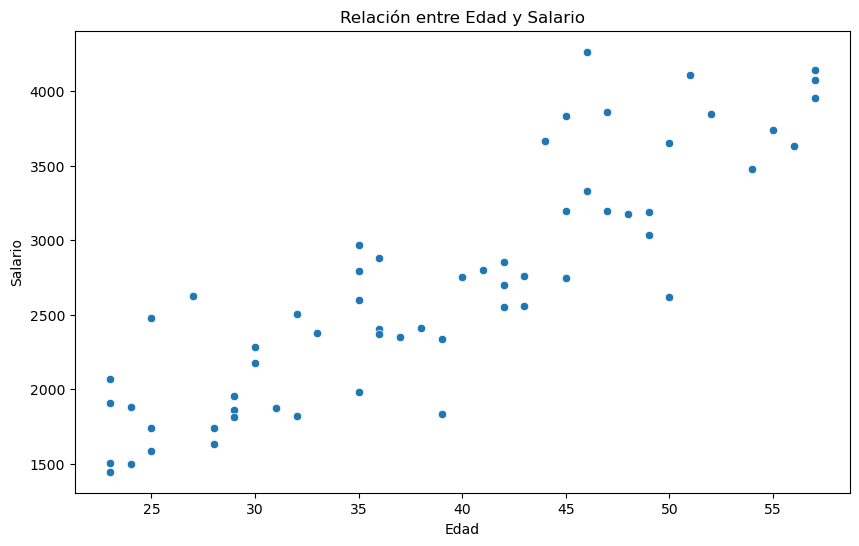

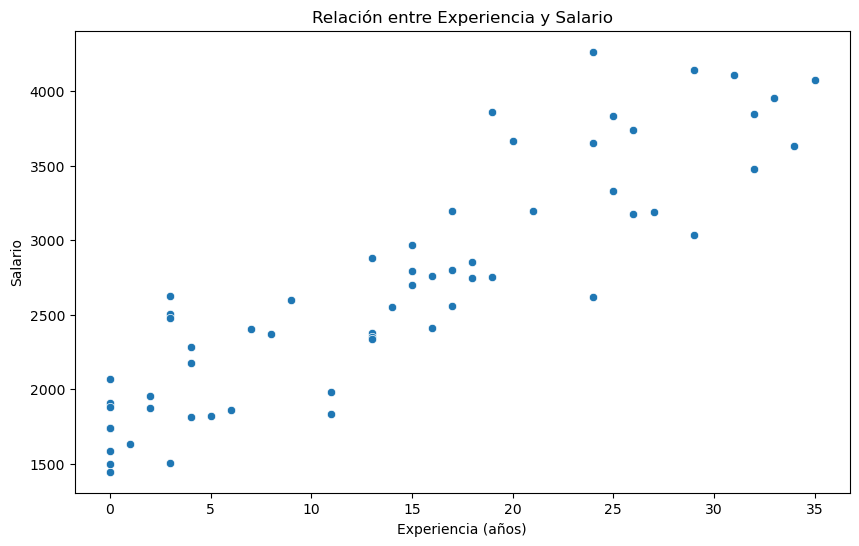

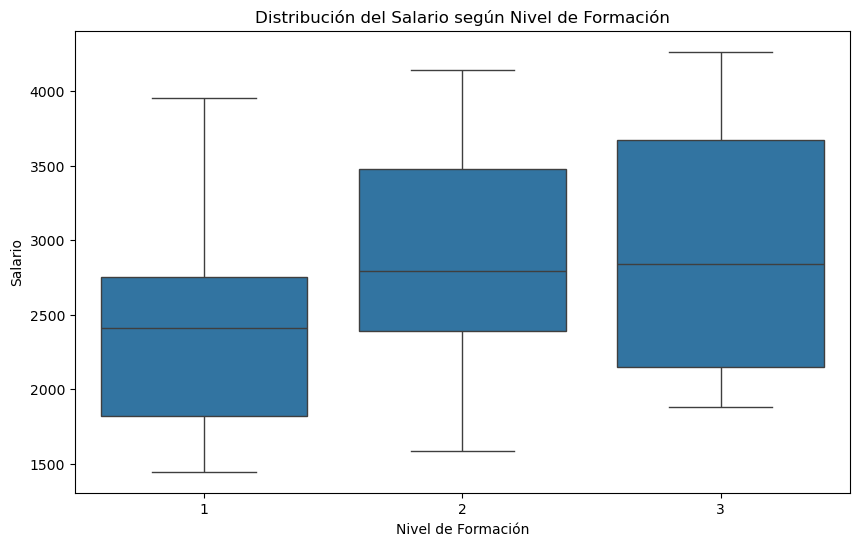

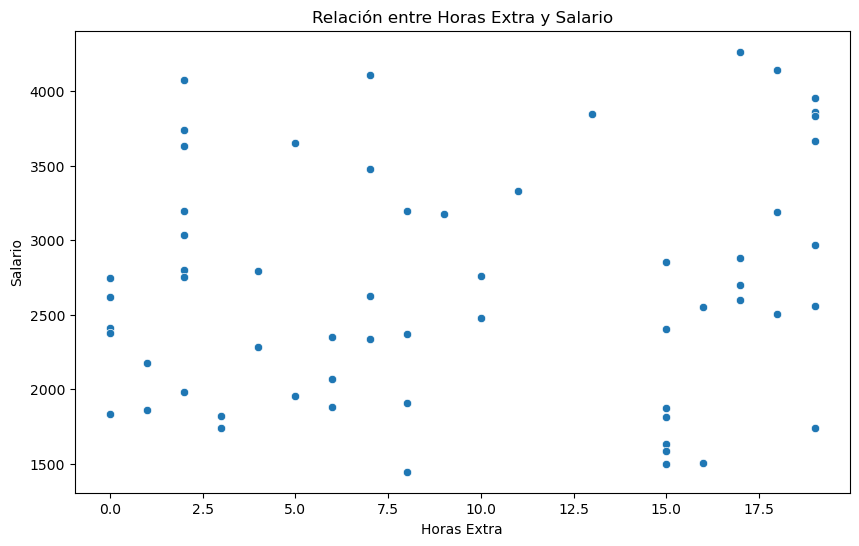

'Las variables que parecen tener mas relacion con salario son: edad y años de experiencia, normalmente \ncon mas experiencia sueles tener un mejor sueldo y esto va a unido tambien a la edad, tambien podemos\napreciar que en el nivel de formacion tambien hay una relacion, grado cobra mas que fp y master cobra mas que grado'

In [31]:
'''2. Análisis exploratorio
- Calcula estadísticas descriptivas básicas.
- Representa gráficamente la relación entre las variables independientes y el salario.
- Comenta brevemente qué variables parecen tener mayor relación con el salario.'''
import matplotlib.pyplot as plt
import seaborn as sns

estadisticas = df_empleados.describe()
print("Estadisticas: ", "\n", estadisticas)

df_empleados = df_empleados.sort_values("salario", ascending=False)

# Gráfico de dispersión para "edad" vs "salario"
plt.figure(figsize=(10, 6))
sns.scatterplot(x="edad", y="salario", data=df_empleados)
plt.title("Relación entre Edad y Salario")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.show()

# Gráfico de dispersión para "experiencia" vs "salario"
plt.figure(figsize=(10, 6))
sns.scatterplot(x="experiencia", y="salario", data=df_empleados)
plt.title("Relación entre Experiencia y Salario")
plt.xlabel("Experiencia (años)")
plt.ylabel("Salario")
plt.show()

# Gráfico de cajas para "formacion" vs "salario"
plt.figure(figsize=(10, 6))
sns.boxplot(x="formacion", y="salario", data=df_empleados)
plt.title("Distribución del Salario según Nivel de Formación")
plt.xlabel("Nivel de Formación")
plt.ylabel("Salario")
plt.show()

# Gráfico de dispersión para "horas_extra" vs "salario"
plt.figure(figsize=(10, 6))
sns.scatterplot(x="horas_extra", y="salario", data=df_empleados)
plt.title("Relación entre Horas Extra y Salario")
plt.xlabel("Horas Extra")
plt.ylabel("Salario")
plt.show()

'''Las variables que parecen tener mas relacion con salario son: edad y años de experiencia, normalmente 
con mas experiencia sueles tener un mejor sueldo y esto va a unido tambien a la edad, tambien podemos
apreciar que en el nivel de formacion tambien hay una relacion, grado cobra mas que fp y master cobra mas que grado'''



In [32]:
'''3. Preparación de los datos
- Separa las variables independientes (X) y la variable dependiente (y).
- Divide el conjunto de datos en conjunto de entrenamiento y de prueba (por ejemplo, 80 % / 20 %).
- Justifica brevemente por qué es necesaria esta división.'''
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

x = df_empleados[["edad", "experiencia", "formacion", "horas_extra"]]
y = df_empleados["salario"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)



In [33]:
'''4. Construcción del modelo
- Crea un modelo de regresión lineal.
- Entrena el modelo con los datos de entrenamiento.
- Muestra la ecuación del modelo obtenido.'''

modelo = LinearRegression()
modelo.fit(x_train, y_train)


LinearRegression()

In [34]:
pd.DataFrame({
    "Variable": x.columns,
    "Coeficiente": modelo.coef_
})

,Variable,Coeficiente
0,edad,4.556448
1,experiencia,58.648222
2,formacion,246.296879
3,horas_extra,19.475477


In [35]:
'''5. Evaluación del modelo
- Realiza predicciones sobre el conjunto de prueba.
- Calcula al menos una métrica de evaluación (R², MAE o MSE).
- Interpreta el resultado obtenido.'''

y_pred = modelo.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2: ", r2)
print("MAE: ", mae)
print("MSE: ", mse)

'''

'''


R2:  0.8998851829827069
MAE:  200.1154842257662
MSE:  80512.67720902346


'\n\n'

In [36]:
'''6. Interpretación
- Explica qué significado tienen los coeficientes del modelo.
- Indica qué variable tiene mayor impacto en el salario según el modelo.
- Comenta una posible limitación del modelo construido'''

'6. Interpretación\n- Explica qué significado tienen los coeficientes del modelo.\n- Indica qué variable tiene mayor impacto en el salario según el modelo.\n- Comenta una posible limitación del modelo construido'